# Análise da Variável Submodalidade

Este notebook tem como objetivo analisar a distribuição da variável **submodalidade**, identificando problemas de alta cardinalidade e categorias raras.

A partir dessa análise, será definido um critério para **redução de cardinalidade**, visando melhorar a performance dos modelos de Machine Learning.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# add raiz do projeto
sys.path.append(os.path.abspath(".."))

In [16]:
df = pd.read_csv("../predictive_models/scrdata_202505.csv", sep=";")

# Filtrar apenas PF
df = df[df["cliente"] == "PF"].copy()

df.head()

,data_base,uf,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,...,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico
2,2025-05-31,AC,Banco,PF,Aposentado/pensionista,Acima de 20 salários mínimos,Empréstimos,"Cartão de crédito - compra, fatura parcelada o...",Sem destinação específica,Prefixado,...,"1655101,22","870379,83","10642,09","4735518,57","3992,52","0,00","3992,52","4739511,09","0,00","55249,15"
3,2025-05-31,AC,Banco,PF,Aposentado/pensionista,Acima de 20 salários mínimos,Empréstimos,Cartão de crédito - não migrado,Sem destinação específica,Prefixado,...,"2802,28","5221,75","0,00","10375,92","48457,26","196037,41","244494,67","254870,59","196037,41","209644,04"
4,2025-05-31,AC,Banco,PF,Aposentado/pensionista,Acima de 20 salários mínimos,Empréstimos,Cheque especial,Sem destinação específica,Prefixado,...,"0,00","0,00","0,00","288563,22","664,40","334,50","998,90","289562,12","334,50","998,90"
5,2025-05-31,AC,Banco,PF,Aposentado/pensionista,Acima de 20 salários mínimos,Empréstimos,Conta Garantida,Sem destinação específica,Prefixado,...,"0,00","0,00","0,00","182,59","0,00","0,00","0,00","182,59","0,00","0,00"
6,2025-05-31,AC,Banco,PF,Aposentado/pensionista,Acima de 20 salários mínimos,Empréstimos,Crédito pessoal - com consignação em folha de ...,Sem destinação específica,Prefixado,...,"8272003,18","6686298,73","43782,77","34616638,49","230240,41","131221,35","361461,76","34978100,25","856874,26","1871224,87"


## Análise Inicial da Variável Submodalidade

Vamos verificar:
- Quantidade de categorias
- Frequência das mais comuns
- Frequência das mais raras

In [17]:
freq = df["submodalidade"].value_counts()

print("Quantidade de categorias:", df["submodalidade"].nunique())

print("\nTop 20 categorias:")
print(freq.head(20))

print("\nCategorias mais raras:")
print(freq.tail(20))

Quantidade de categorias: 50

Top 20 categorias:
submodalidade
Crédito pessoal - sem consignação em folha de pagam.                                                               16523
Cartão de crédito - compra à vista e parcelado lojista                                                             12904
Investimento                                                                                                       10528
Outros empréstimos                                                                                                 10054
Crédito pessoal - com consignação em folha de pagam.                                                                9741
Aquisição de bens - outros bens                                                                                     8740
Crédito rotativo vinculado a cartão de crédito                                                                      8531
Cartão de crédito - não migrado                                                           

## Estatísticas da Distribuição

A análise estatística permite entender a dispersão dos dados e identificar a presença de categorias com baixa representatividade.

In [18]:
freq.describe()

count       50.000000
mean      3652.620000
std       4153.480433
min          1.000000
25%        198.000000
50%       1413.500000
75%       7153.500000
max      16523.000000
Name: count, dtype: float64

## Interpretação

A variável apresenta uma distribuição de **cauda longa (long tail)**:

- Poucas categorias concentram grande parte dos dados
- Muitas categorias possuem baixa frequência (algumas com menos de 10 ocorrências)

Isso pode causar:
- Overfitting
- Ruído no modelo
- Aumento desnecessário de dimensionalidade após One-Hot Encoding

Portanto, é necessário aplicar uma estratégia de **agrupamento de categorias raras**.

## Teste de Thresholds

Nesta etapa, avaliamos diferentes valores de corte (threshold), verificando:

- Quantas categorias seriam mantidas
- Qual percentual dos dados seria preservado

In [19]:
print("Impacto de diferentes thresholds:\n")

for t in [50, 100, 200, 500, 1000]:
    n_categorias = (freq > t).sum()
    cobertura = freq[freq > t].sum() / freq.sum()

    print(f"Threshold {t}:")
    print(f"  - Categorias mantidas: {n_categorias}")
    print(f"  - Cobertura dos dados: {cobertura:.2%}")

Impacto de diferentes thresholds:

Threshold 50:
  - Categorias mantidas: 44
  - Cobertura dos dados: 99.98%
Threshold 100:
  - Categorias mantidas: 40
  - Cobertura dos dados: 99.82%
Threshold 200:
  - Categorias mantidas: 37
  - Cobertura dos dados: 99.57%
Threshold 500:
  - Categorias mantidas: 33
  - Cobertura dos dados: 99.00%
Threshold 1000:
  - Categorias mantidas: 30
  - Cobertura dos dados: 97.66%


## Escolha do Threshold

O valor de **1000** foi escolhido com base nos seguintes critérios:

- Redução significativa da cardinalidade (de 50 para ~30 categorias)
- Preservação de aproximadamente **97% dos dados**
- Remoção de categorias com baixa relevância estatística

Esse valor representa um bom equilíbrio entre:
- **Simplicidade do modelo**
- **Preservação da informação**

Além disso, o valor está próximo da mediana da distribuição, reforçando sua adequação.

## Visualização das Principais Categorias

Gráfico das 20 submodalidades mais frequentes.

/tmp/ipykernel_10092/1887317457.py:11: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/milena-hamerski/Documents/UTFPR/TCC/analise_ds/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


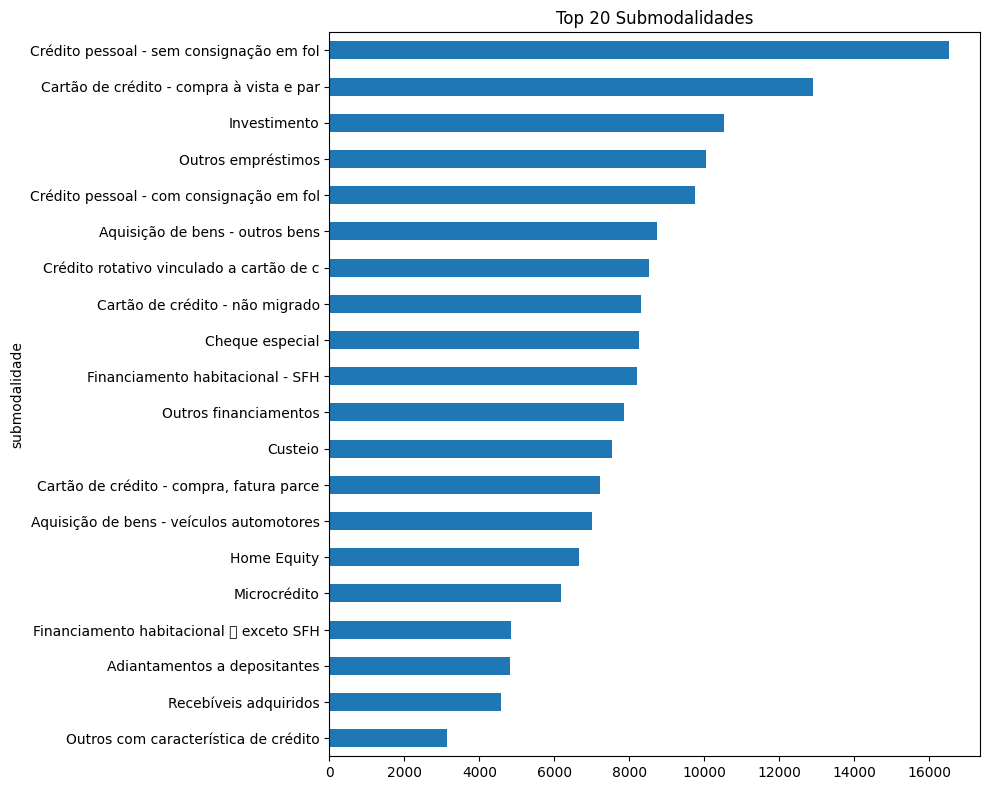

In [20]:
plt.figure(figsize=(10, 8))

freq_plot = freq.head(20).sort_values()

freq_plot.index = freq_plot.index.str.slice(0, 40)

freq_plot.plot(kind="barh")

plt.title("Top 20 Submodalidades")

plt.tight_layout()
plt.show()

## ✅ Conclusão

A variável `submodalidade` apresentava alta cardinalidade e presença de muitas categorias raras.

Foi aplicada uma estratégia de agrupamento baseada em frequência, onde:

- Categorias com menos de 1000 ocorrências são agrupadas em "Outros"
- Mantém-se a maior parte da informação relevante
- Reduz-se o risco de overfitting

Essa abordagem contribui para:
- Melhor generalização do modelo
- Redução da dimensionalidade
- Maior estabilidade nos resultados